## Geocalibration ZL048 and ZR048

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import plotly.express as px
from plotly.subplots import make_subplots
from typing import List

In [2]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i


Here we load the data for ZL048 and ZR048

In [3]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

Number of data points for zl048:	38
Number of data points for zr048:	248


Here we display what we think are outliers and subsequently remove them

In [4]:
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []

zl_outliers = zl.iloc[zl_outlier_idx,:]
zr_outliers = zr.iloc[zr_outlier_idx,:]

fig = make_subplots(rows=1, cols=2, subplot_titles=["ZL048", "ZR048"])

# focal length - fmc plot for ZL048
left_scatter_all = px.scatter(zl, x="fmc", y="f_est", hover_data=[zl.index])
left_scatter_outliers = px.scatter(zl_outliers, x="fmc", y="f_est", hover_data=[zl_outliers.index])
left_scatter_outliers.update_traces(marker=dict(color="red"))
fig.add_trace(left_scatter_all.data[0], row=1, col=1)
fig.add_trace(left_scatter_outliers.data[0], row=1, col=1)

# focal lenth - fmc plot for ZR048
right_scatter_all = px.scatter(zr, x="fmc", y="f_est", hover_data=[zr.index])
right_scatter_outliers = px.scatter(zr_outliers, x="fmc", y="f_est", hover_data=[zr_outliers.index])
right_scatter_outliers.update_traces(marker=dict(color="red"))
fig.add_trace(right_scatter_all.data[0], row=1, col=2)
fig.add_trace(right_scatter_outliers.data[0], row=1, col=2)


fig.update_layout(width=1000, height=400, title="f_est vs fmc for ZL048 and ZR048")

In [5]:
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  
  outlier_removed = True
  
zr = zr[zr["fmc"]>1590]
zr = zr[zr["fmc"]<2000].reset_index(drop=True)

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	68


## Rotation Fitting

Here we assume the value of the rotation $R^r_{r'}$ from the fit given by ZL034 and ZR034 and we seek to find the rotation $R^m_c$. From the transformations we have

$$R^m_c = (R^r_{r'} R^{r'}_m)^T H^r (H^c)^{-1}$$

Let the quaternion related to the $R^m_c$ be $q^m_c$ and let the quaternion calculated from data be $q^m_{c,data}$. Then we seek to find $q^m_{c,model}$ that solves the following

$$ \min_{q^m_{c,model}} \sum_i \arccos(2 \langle q^m_{c,i,model}, q^m_{c,i,data} \rangle^2 -1) $$

In [6]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)
  
  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

def gen_rot_obj(data_:pd.DataFrame)->callable:
  data__ = data_.copy()
  rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])

  def rot_obj(x_:List):
  
    assert len(x_) == 8

    total_cost = 0
    for i in range(data__.shape[0]):
      # calc rotation from model
      f = data__["fmc"][i]
      rot_mc_0 = R.from_quat(x_[:4])
      rot_mc_1 = R.from_quat(x_[4:8])
      rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
      q_mc_model = rot_mc_model.as_quat(canonical=True)

      # calc rotation from data
      fl = data__["f_est"][i]
      b1,b2 = data__["b1_est"][i], data__["b2_est"][i]
      cx, cy = data__["cx_est"][i], data_["cy_est"][i]
      Hc_inv =  np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])

      rot_rpm = R.from_matrix(data__["R_rpm_mat"][i])
      Hr = get_H_r_data(i, data__)

      rot_mc_data = (rot_rrp * rot_rpm).as_matrix().T @ Hr @ Hc_inv
      q_mc_data = R.from_matrix(rot_mc_data).as_quat(canonical=True)

      # calc and add to total cost
      total_cost += dist_q(q_mc_data, q_mc_model)

    
    return (total_cost/data__.shape[0])
  
  return rot_obj


# left optimization
left_rot_obj = gen_rot_obj(zl)
x0_left = [0.44, 0.56, 0.50, 0.491, 
           0.01, 0.01, 0.01, 1]
left_res = minimize(left_rot_obj, x0_left, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})
q_mc_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
q_mc_zl_1 = np.array(left_res.x[4:8])

print(f"Left optimization")
print(f"Final function value:\t{left_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
print(f"q_cm_zl_0:\t\t{q_mc_zl_0}")
print(f"q_cm_zl_1:\t\t{q_mc_zl_1}")
print('-'*100)


# right optimization
right_rot_obj = gen_rot_obj(zr)
x0_right = [0.4785, 0.467, 0.530, 0.5215,
             0.01, 0.01, 0.01, 1]
right_res = minimize(right_rot_obj, x0_right, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})
q_mc_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
q_mc_zr_1 = np.array(right_res.x[4:8])

print(f"Right optimization")
print(f"Final function value:\t{right_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
print(f"q_cm_zl_0:\t\t{q_mc_zr_0}")
print(f"q_cm_zl_1:\t\t{q_mc_zr_1}")
print('-'*100)

Left optimization
Final function value:	0.001172
Final Jacobian value:	0.001921
q_cm_zl_0:		[0.44377992 0.5625695  0.49968724 0.48671101]
q_cm_zl_1:		[-2.32039184e-03 -7.76827219e-04 -1.64998431e-03  9.99950642e-01]
----------------------------------------------------------------------------------------------------
Right optimization
Final function value:	0.001685
Final Jacobian value:	0.001509
q_cm_zl_0:		[0.47604735 0.4667977  0.53088594 0.5231051 ]
q_cm_zl_1:		[ 1.34150488e-03 -2.22995243e-04  7.61029171e-04  1.00257474e+00]
----------------------------------------------------------------------------------------------------


Plotting the fits in the quaterion space

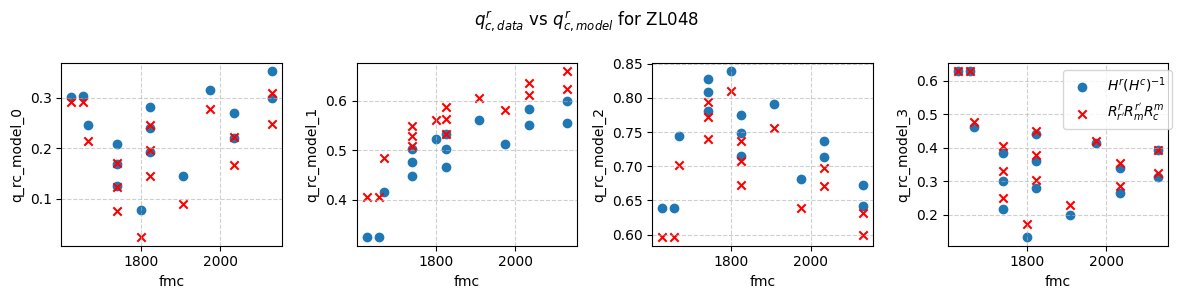

In [33]:
q_rc_data_left, q_rc_model_left = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
for i in range(zl.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  q_rc_data_left.append(R.from_matrix(Hr @ Hc_inv).as_quat(canonical=True))

  # compute q_mc using model
  f = zl["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  q_rc_model_left.append((rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zl["fmc"], [q[i] for q in q_rc_data_left], label="$H^r(H^c)^{-1}$")
  ax[i].scatter(zl["fmc"], [q[i] for q in q_rc_model_left], marker='x', color='red',
                label="$R^r_{r'}R^{r'}_mR^m_c$")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_rc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZL048")
fig.tight_layout()



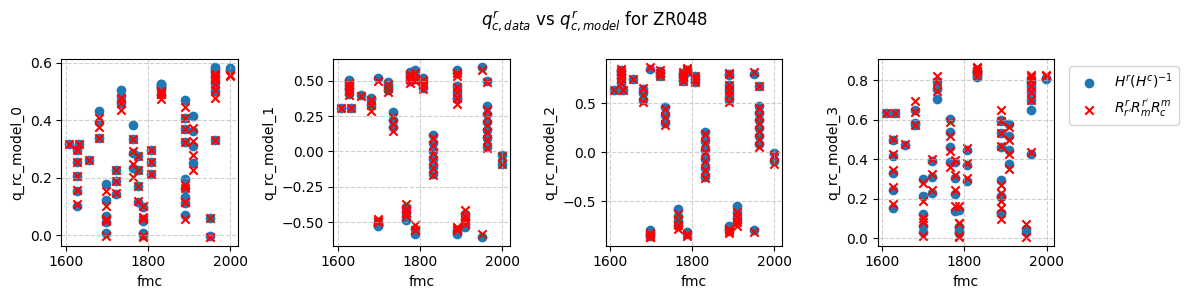

In [34]:
q_rc_data_right, q_rc_model_right = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
for i in range(zr.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  q_rc_data_right.append(R.from_matrix(Hr @ Hc_inv).as_quat(canonical=True))

  # compute q_mc using model
  f = zr["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  q_rc_model_right.append((rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zr["fmc"], [q[i] for q in q_rc_data_right], label="$H^r(H^c)^{-1}$")
  ax[i].scatter(zr["fmc"], [q[i] for q in q_rc_model_right], marker='x', color='red',
                label="$R^r_{r'}R^{r'}_mR^m_c$")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_rc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZR048")
fig.tight_layout()

plotting the fits for $q^m_c$

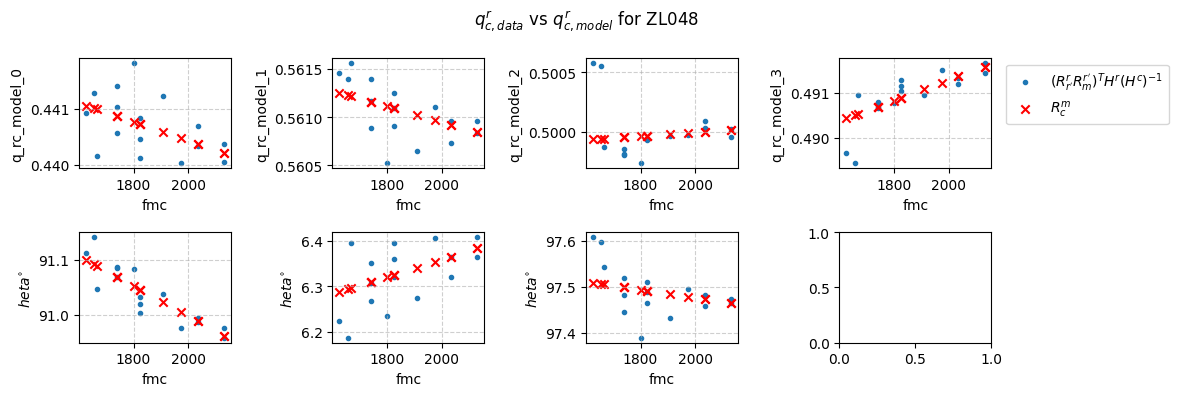

In [41]:
q_mc_data_left, q_mc_model_left = [], []
eu_mc_data_left, eu_mc_model_left = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
for i in range(zl.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zl)
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)
  q_mc_data_left.append(rot_mc_data.as_quat(canonical=True))
  eu_mc_data_left.append(rot_mc_data.as_euler("xyz", degrees=True))

  # compute q_mc using model
  f = zl["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
  q_mc_model_left.append(rot_mc_model.as_quat(canonical=True))
  eu_mc_model_left.append(rot_mc_model.as_euler("xyz", degrees=True))
  

# plot 
fig, ax = plt.subplots(2, 4, figsize=(12,4))
for i in range(4):
  ax[0,i].scatter(zl["fmc"], [q[i] for q in q_mc_data_left], marker='.',
                   label="$(R^r_{r'}R^{r'}_m)^TH^r(H^c)^{-1}$")
  ax[0,i].scatter(zl["fmc"], [q[i] for q in q_mc_model_left], marker='x', color='red',
                label="$R^m_c$")
  ax[0,i].set_xlabel(f"fmc")
  ax[0,i].set_ylabel(f"q_rc_model_{i}")
  ax[0,i].grid(linestyle="--", alpha=0.6)

for i, angle in enumerate(["x", "y", "z"]):
  ax[1,i].scatter(zl["fmc"], [eu[i] for eu in eu_mc_data_left], marker='.')
  ax[1,i].scatter(zl["fmc"], [eu[i] for eu in eu_mc_model_left],
                  marker='x', color='red')
  ax[1,i].set_xlabel("fmc")
  ax[1,i].set_ylabel("$\theta^{\circ}$")
  ax[1,i].grid(linestyle="--", alpha=0.6)

ax[0, 3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZL048")
fig.tight_layout()

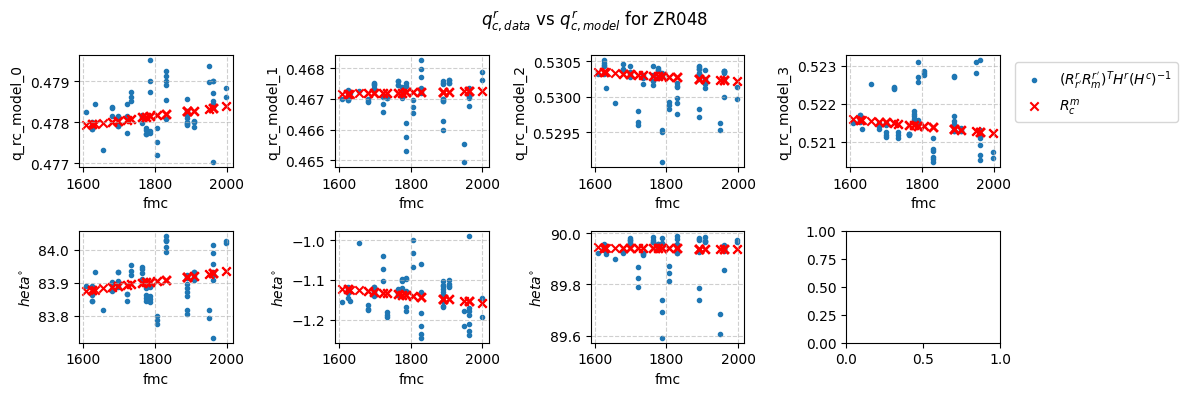

In [40]:
q_mc_data_right, q_mc_model_right = [], []
eu_mc_data_right, eu_mc_model_right = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
for i in range(zr.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zr)
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)
  q_mc_data_right.append(rot_mc_data.as_quat(canonical=True))
  eu_mc_data_right.append(rot_mc_data.as_euler("xyz", degrees=True))

  # compute q_mc using model
  f = zr["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
  q_mc_model_right.append(rot_mc_model.as_quat(canonical=True))
  eu_mc_model_right.append(rot_mc_model.as_euler("xyz", degrees=True))
  

# plot 
fig, ax = plt.subplots(2, 4, figsize=(12,4))
for i in range(4):
  ax[0,i].scatter(zr["fmc"], [q[i] for q in q_mc_data_right], marker='.',
                  label="$(R^r_{r'}R^{r'}_m)^TH^r(H^c)^{-1}$")
  ax[0,i].scatter(zr["fmc"], [q[i] for q in q_mc_model_right], marker='x', color='red',
                label="$R^m_c$")
  ax[0,i].set_xlabel(f"fmc")
  ax[0,i].set_ylabel(f"q_rc_model_{i}")
  ax[0,i].grid(linestyle="--", alpha=0.6)

for i, angle in enumerate(["x", "y", "z"]):
  ax[1,i].scatter(zr["fmc"], [eu[i] for eu in eu_mc_data_right], marker='.')
  ax[1,i].scatter(zr["fmc"], [eu[i] for eu in eu_mc_model_right], marker='x', color='red')
  ax[1,i].set_xlabel("fmc")
  ax[1,i].set_ylabel("$\theta^{\circ}$")
  ax[1,i].grid(linestyle="--", alpha=0.6)

ax[0, 3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZR048")
fig.tight_layout()

plotting the fits for $R^r_c$

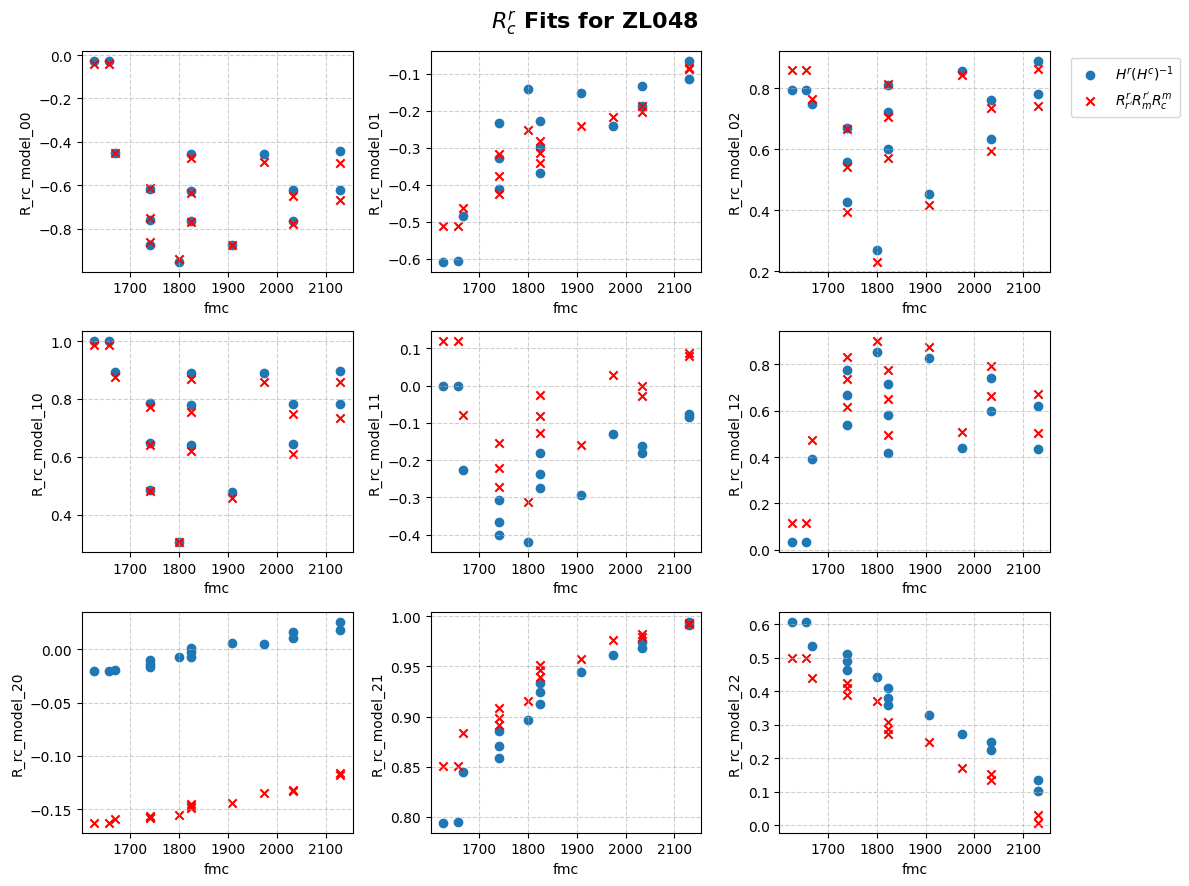

In [9]:
R_rc_data_left, R_rc_model_left = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
for i in range(zl.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  R_rc_data_left.append(R.from_matrix(Hr @ Hc_inv).as_matrix())

  # compute q_mc using model
  f = zl["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  R_rc_model_left.append((rot_rrp * rot_rpm * rot_mc).as_matrix())

# plot 
fig, ax = plt.subplots(3, 3, figsize=(12,9))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [R[i,j] for R in R_rc_data_left], label="$H^r(H^c)^{-1}$")
    ax[i,j].scatter(zl["fmc"], [R[i,j] for R in R_rc_model_left], marker='x', color='red',
                  label="$R^r_{r'}R^{r'}_mR^m_c$")
    ax[i,j].set_xlabel(f"fmc")
    ax[i,j].set_ylabel(f"R_rc_model_{i}{j}")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$R^r_c$ Fits for ZL048", fontsize=16, fontweight='bold')
fig.tight_layout()

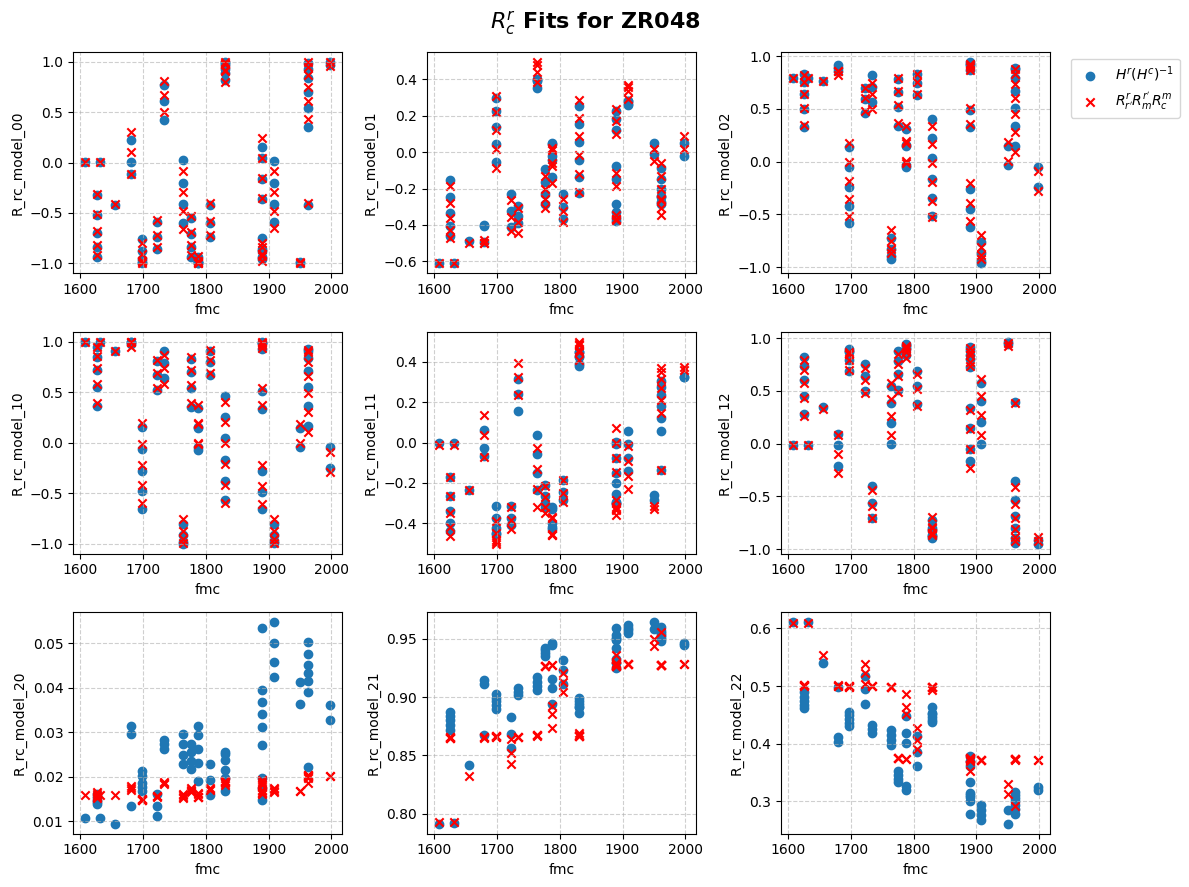

In [10]:
R_rc_data_right, R_rc_model_right = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
for i in range(zr.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  R_rc_data_right.append(R.from_matrix(Hr @ Hc_inv).as_matrix())

  # compute q_mc using model
  f = zr["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  R_rc_model_right.append((rot_rrp * rot_rpm * rot_mc).as_matrix())

# plot 
fig, ax = plt.subplots(3, 3, figsize=(12,9))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [R[i,j] for R in R_rc_data_right], label="$H^r(H^c)^{-1}$")
    ax[i,j].scatter(zr["fmc"], [R[i,j] for R in R_rc_model_right], marker='x', color='red',
                  label="$R^r_{r'}R^{r'}_mR^m_c$")
    ax[i,j].set_xlabel(f"fmc")
    ax[i,j].set_ylabel(f"R_rc_model_{i}{j}")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$R^r_c$ Fits for ZR048", fontsize=16, fontweight='bold')
fig.tight_layout()

Plotting the fits for $H^r$



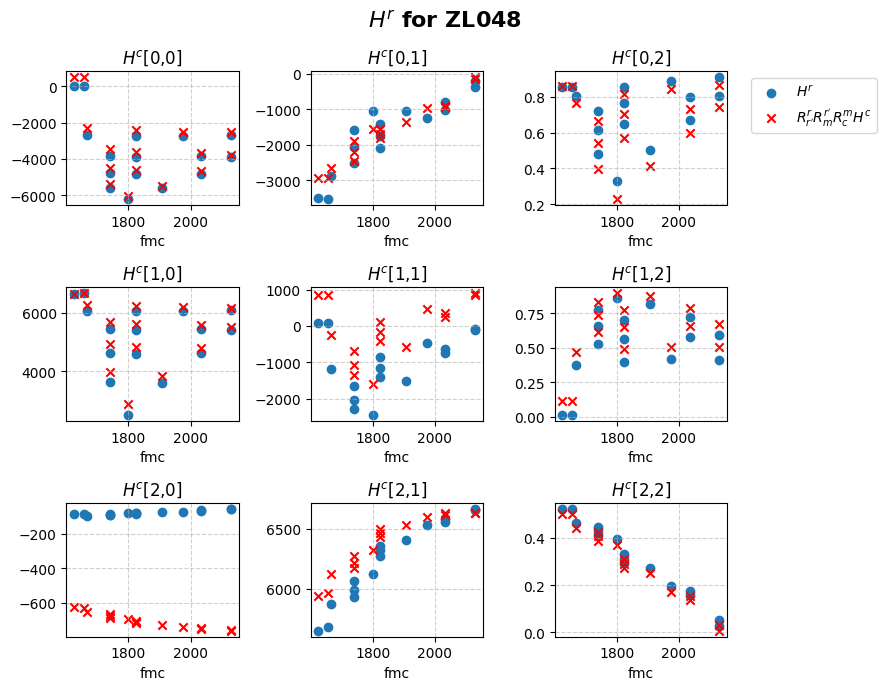

In [11]:
hr_data_left, hr_model_left = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)

for i in range(zl.shape[0]):
  # compute Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hc from model
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  f = zl["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  
  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hr_model_left.append(R_rc @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_model_left], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()


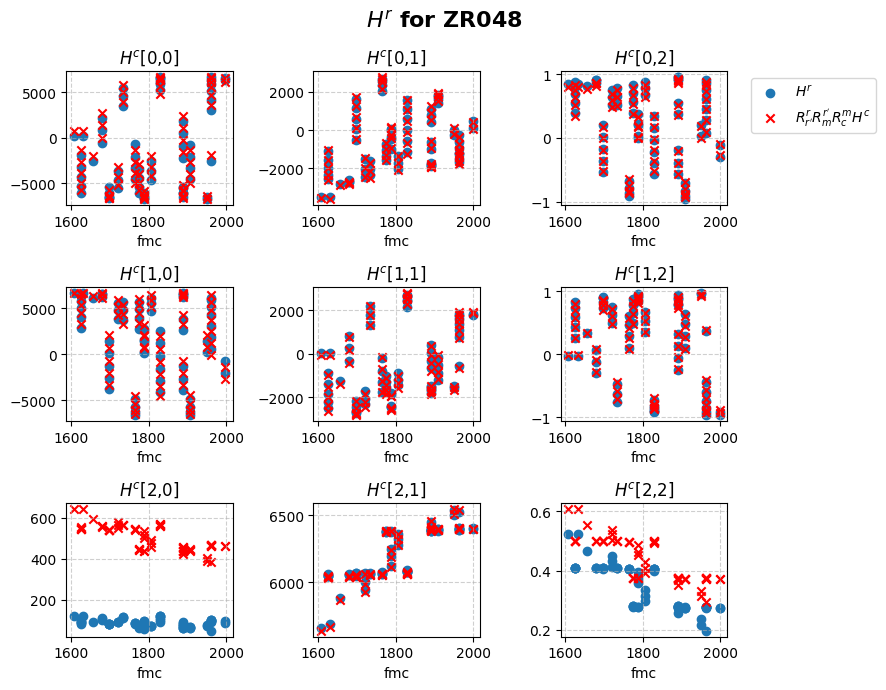

In [12]:
hr_data_right, hr_model_right = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)

for i in range(zr.shape[0]):
  # compute Hr from data
  hr_data_right.append(get_H_r_data(i, zr))

  # compute Hc from model
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  
  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hr_model_right.append(R_rc @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_data_right], label="$H^r$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_model_right], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

Plotting the $H^c$

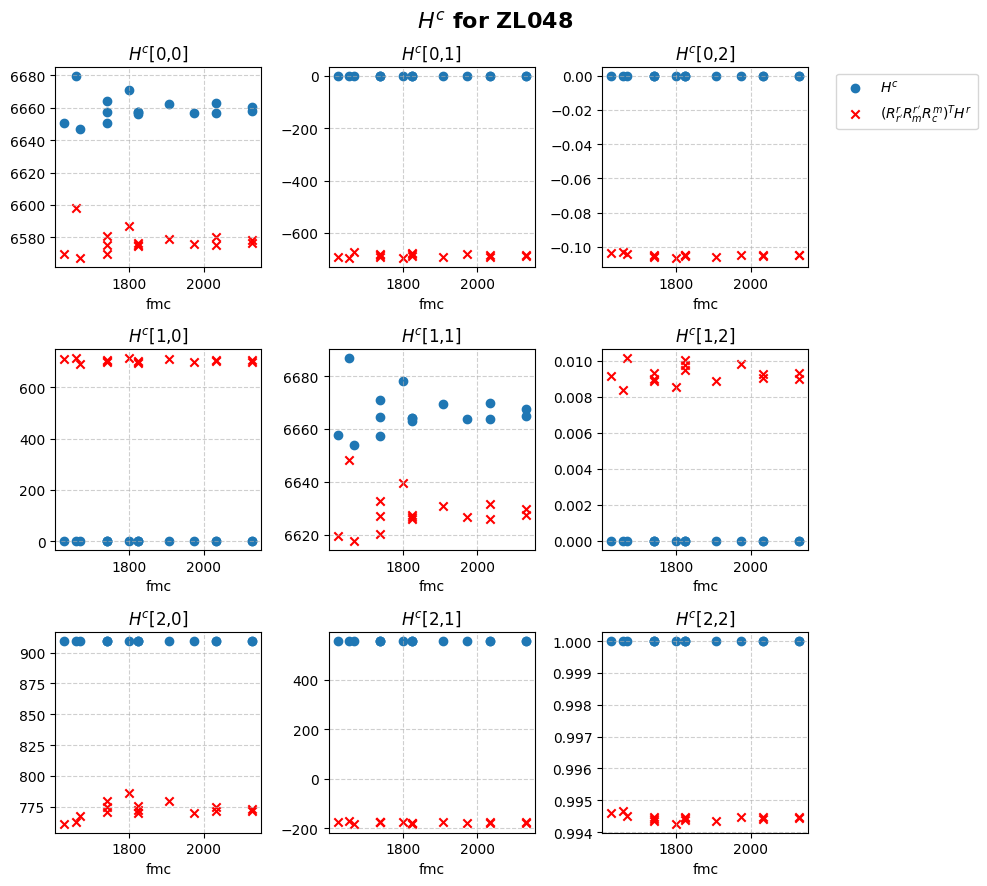

In [13]:
hc_data_left, hc_model_left = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)

for i in range(zl.shape[0]):
  # compute Hr from data
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  hc_data_left.append(hc)

  # compute Hc from model
  hr = get_H_r_data(i, zl)
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  f = zl["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  
  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hc_model_left.append(R_rc.T @ hr)

# plot
fig, ax = plt.subplots(3, 3, figsize=(10,9))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hc_data_left], label="$H^c$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hc_model_left], 
                    marker="x", color="red",
                    label="$(R^r_{r'}R^{r'}_mR^m_c)^TH^r$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^c$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

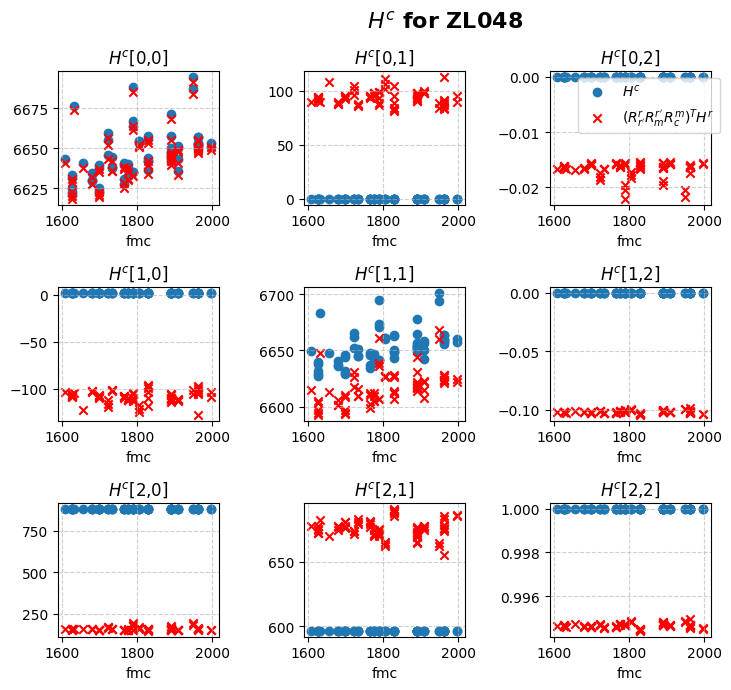

In [14]:
hc_data_right, hc_model_right = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)

for i in range(zr.shape[0]):
  # compute Hr from data
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  hc_data_right.append(hc)

  # compute Hc from model
  hr = get_H_r_data(i, zr)
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))
  
  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hc_model_right.append(R_rc.T @ hr)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hc_data_right], label="$H^c$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hc_model_right], 
                    marker="x", color="red",
                    label="$(R^r_{r'}R^{r'}_mR^m_c)^TH^r$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^c$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

## Error analysis

Here we would study how deviations in the value of the quaternion affects the values of $H^r$

Here we compute the additive error to the queternion $q^m_c$

In [52]:
error_left = []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
for i in range(zl.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zl)
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)

  # compute q_mc using model
  f = zl["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))

  error_left.append(rot_mc_data.as_quat(canonical=True) - rot_mc_model.as_quat(canonical=True))

# compute the standard deviations in the error
std_left = np.array(error_left).std(axis=0)
print(f"Std of error for ZL048: {std_left}")

error_right = []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
for i in range(zr.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zr)
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)

  # compute q_mc using model
  f = zr["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))

  error_right.append(rot_mc_data.as_quat(canonical=True) - rot_mc_model.as_quat(canonical=True))

# compute the standard deviations in the error
std_right = np.array(error_right).std(axis=0)
print(f"Std of error for ZR048: {std_right}")

Std of error for ZL048: [0.00047045 0.00024219 0.00023527 0.00037685]
Std of error for ZR048: [0.00048056 0.00057804 0.00029418 0.00069304]


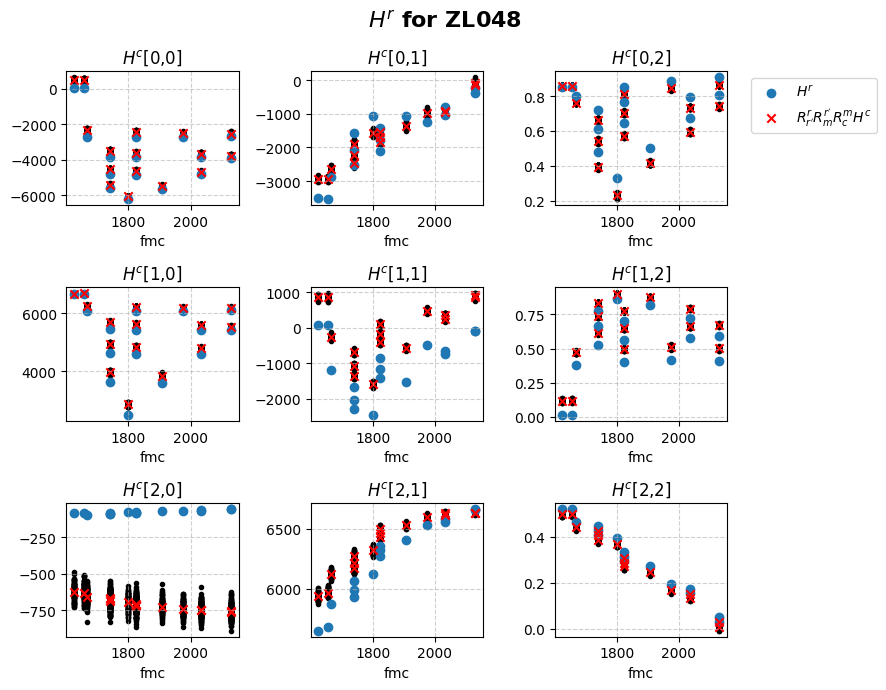

In [87]:
hr_data_left, hr_model_left, hr_sim_left = [], [], []
n = 100

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
std_vec = std_left * 10
for i in range(zl.shape[0]):
  # compute Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hc from model
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  f = zl["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))

  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hr_model_left.append(R_rc @ hc)

  # sample within the error envelope
  for _ in range(n):
    rot_mc_w_err = R.from_quat(rot_mc.as_quat(canonical=True) + np.random.normal(loc=0, scale=std_vec))
    R_rc_w_err = (rot_rrp * rot_rpm * rot_mc_w_err).as_matrix()
    hr_sim_left.append((f, R_rc_w_err @ hc))
  
  

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter([hr[0] for hr in hr_sim_left], [hr[1][i][j] for hr in hr_sim_left],
                    marker='.', color='black')
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_model_left], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

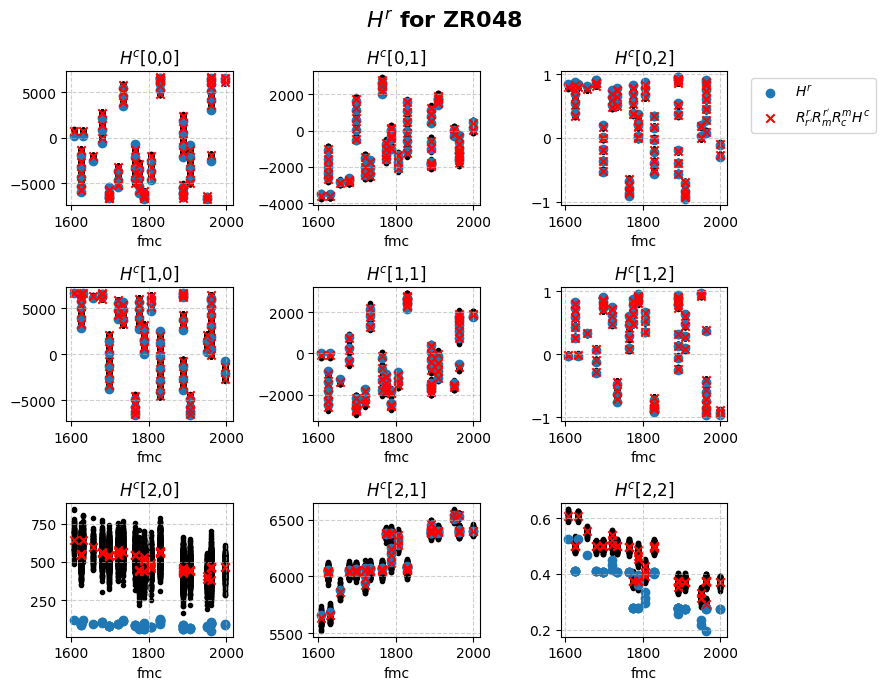

In [88]:
hr_data_right, hr_model_right, hr_sim_right = [], [], []
n = 100

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
std_vec = std_right * 10
for i in range(zr.shape[0]):
  # compute Hr from data
  hr_data_right.append(get_H_r_data(i, zr))

  # compute Hc from model
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))

  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hr_model_right.append(R_rc @ hc)

  # sample within the error envelope
  for _ in range(n):
    rot_mc_w_err = R.from_quat(rot_mc.as_quat(canonical=True) + np.random.normal(loc=0, scale=std_vec))
    R_rc_w_err = (rot_rrp * rot_rpm * rot_mc_w_err).as_matrix()
    hr_sim_right.append((f, R_rc_w_err @ hc))
  
  

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter([hr[0] for hr in hr_sim_right], [hr[1][i][j] for hr in hr_sim_right],
                    marker='.', color='black')
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_data_right], label="$H^r$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_model_right], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

Here we compute the additive error in terms of euler angles 

In [89]:
error_left = []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
for i in range(zl.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zl)
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)
  eu_mc_data = rot_mc_data.as_euler("xyz", degrees=True)

  # compute q_mc using model
  f = zl["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
  eu_mc_model = rot_mc_model.as_euler("xyz", degrees=True)

  error_left.append(eu_mc_data - eu_mc_model)

# compute the standard deviations in the error
std_left = np.array(error_left).std(axis=0)
print(f"Std of error for ZL048: {std_left}")

error_right = []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
for i in range(zr.shape[0]):
  # compute q_mc from data
  R_rpm = get_R_rpm(i, zr)
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  rot_mc_data = R.from_matrix((R_rrp @ R_rpm).T @ Hr @ Hc_inv)
  eu_mc_data = rot_mc_data.as_euler("xyz", degrees=True)

  # compute q_mc using model
  f = zr["fmc"][i]
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
  eu_mc_model = rot_mc_model.as_euler("xyz", degrees=True)

  error_right.append(eu_mc_data - eu_mc_model)

# compute the standard deviations in the error
std_right = np.array(error_right).std(axis=0)
print(f"Std of error for ZR048: {std_right}")

Std of error for ZL048: [0.02477521 0.05664313 0.04915244]
Std of error for ZR048: [0.06566425 0.05252848 0.08751545]


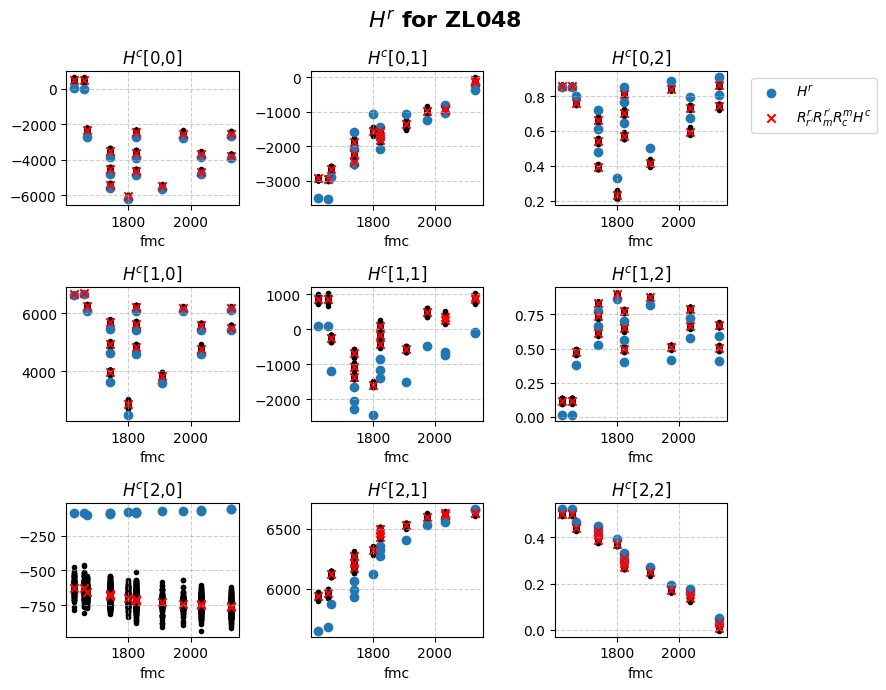

In [92]:
hr_data_left, hr_model_left, hr_sim_left = [], [], []
n = 100

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zl_0)
rot_mc_1 = R.from_quat(q_mc_zl_1)
std_vec = std_left * 10
for i in range(zl.shape[0]):
  # compute Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hc from model
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  f = zl["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))

  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()
  hr_model_left.append(R_rc @ hc)

  # sample within the error envelope
  for _ in range(n):
    rot_err = R.from_euler("xyz", np.random.normal(loc=0, scale=std_vec), degrees=True)
    R_rc_w_err = (rot_rrp * rot_rpm * rot_mc * rot_err).as_matrix()
    hr_sim_left.append((f, R_rc_w_err @ hc))
  
  

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter([hr[0] for hr in hr_sim_left], [hr[1][i][j] for hr in hr_sim_left],
                    marker='.', color='black')
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_model_left], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

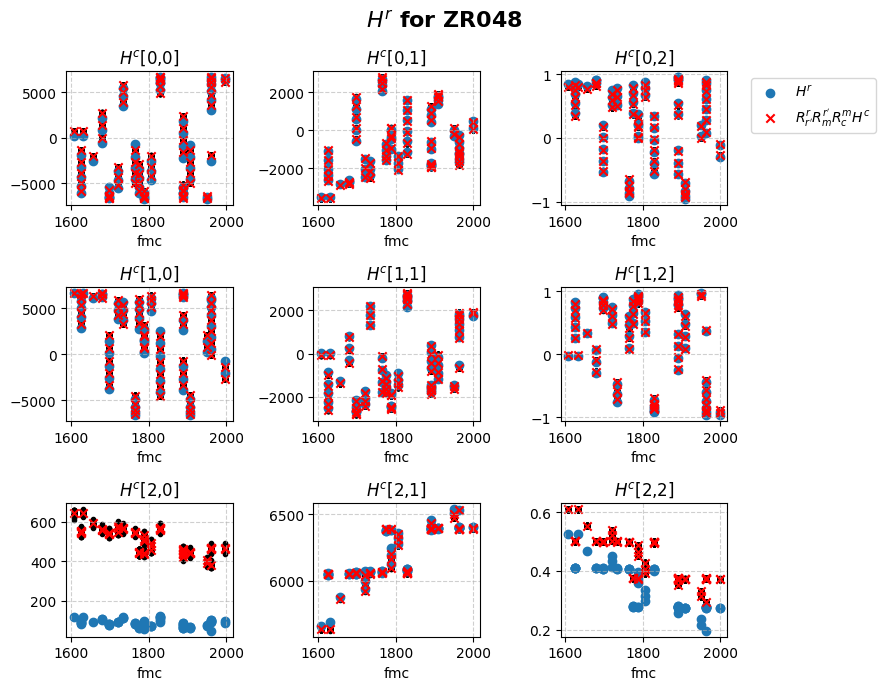

In [111]:
hr_data_right, hr_model_right, hr_sim_right = [], [], []
n = 100

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
std_vec = std_right 
for i in range(zr.shape[0]):
  # compute Hr from data
  hr = get_H_r_data(i, zr)
  hr_data_right.append(hr)

  # compute Hc from model
  hc = [[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))

  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()

  hr_model_right.append(R_rc @ hc)
  q_rc_model_right.append((rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True))

  # sample within the error envelope
  for _ in range(n):
    rot_err = R.from_euler("xyz", np.random.normal(loc=0, scale=std_vec), degrees=True)
    
    rot_rc_w_err = rot_rrp * rot_rpm * rot_err * rot_mc
    R_rc_w_err = rot_rc_w_err.as_matrix()
    
    hr_sim_right.append((f, R_rc_w_err @ hc))
  

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter([hr[0] for hr in hr_sim_right], [hr[1][i][j] for hr in hr_sim_right],
                    marker='.', color='black')
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_data_right], label="$H^r$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_model_right], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

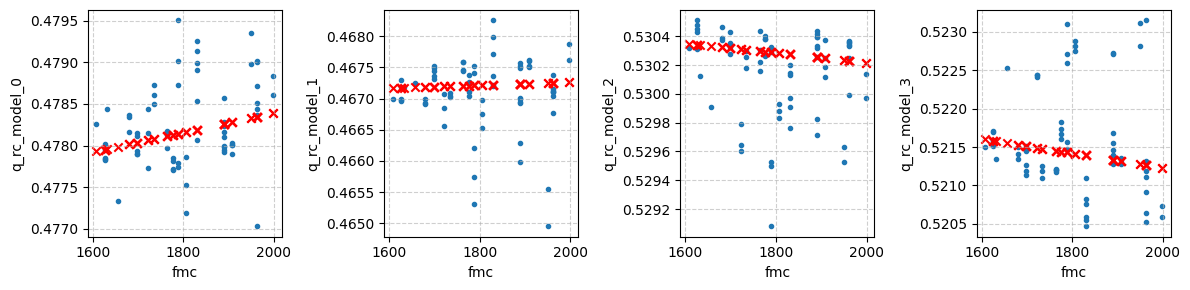

In [110]:
q_rc_data_right, q_rc_model_right, q_rc_sim_right = [], [], []
n = 100

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_mc_0 = R.from_quat(q_mc_zr_0)
rot_mc_1 = R.from_quat(q_mc_zr_1)
std_vec = [0.01, 0.01, 0.01, 0.01]
for i in range(zr.shape[0]):
  # compute q_rc from data
  hr = get_H_r_data(i, zr)  
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  rot_rc_data = R.from_matrix(hr @ hc_inv)
  q_rc_data_right.append(rot_rc_data.as_quat(canonical=True))

  # compute Hc from model
  hc = [[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]]
  
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  f = zr["fmc"][i]
  rot_mc = rot_mc_0 * (rot_mc_1 ** (f/1000))

  R_rc = (rot_rrp * rot_rpm * rot_mc).as_matrix()

  hr_model_right.append(R_rc @ hc)
  q_rc_model_right.append((rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True))


# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter([q_rc[0] for q_rc in q_rc_sim_right], 
                [q_rc[1][i] for q_rc in q_rc_sim_right],
                marker='.', color='black')
  ax[i].scatter(zr["fmc"], [q[i] for q in q_mc_data_right], marker='.',
                  label="$(R^r_{r'}R^{r'}_m)^TH^r(H^c)^{-1}$")
  ax[i].scatter(zr["fmc"], [q[i] for q in q_mc_model_right], marker='x', color='red',
                label="$R^m_c$")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_rc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

fig.tight_layout()